## To Plot Result Graphs on Benchmark CSV

Loaded 1640 valid benchmark entries
Solvers: ['EquSolver' 'GridSolver' 'BrbSolver' 'MsrbSolver']
Cores: [1, 2, 4, 8]


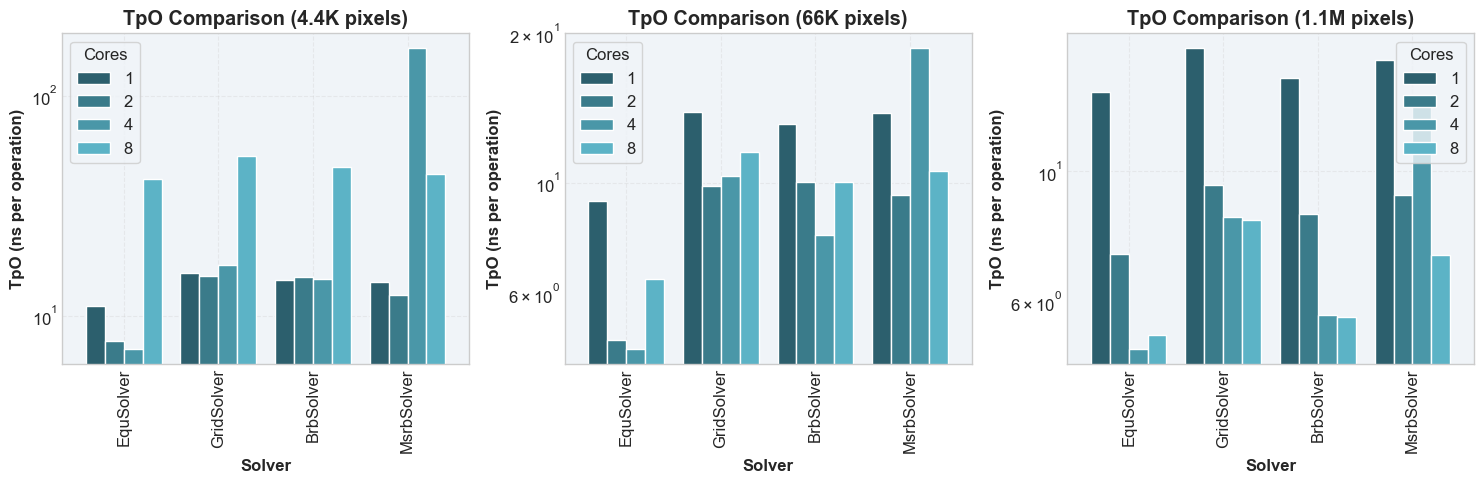

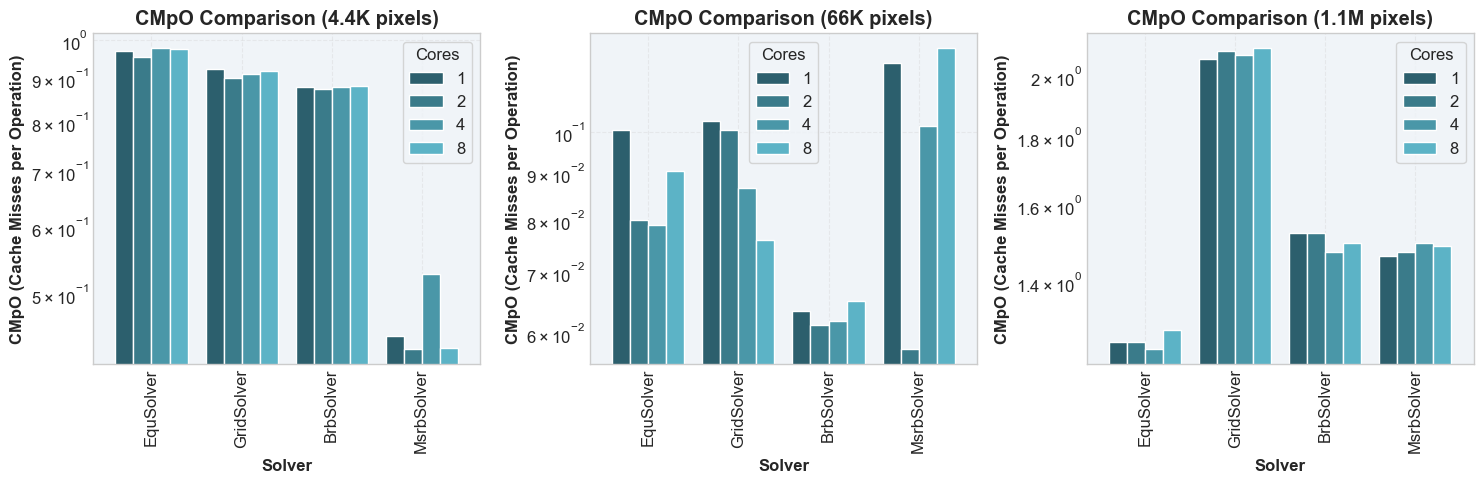

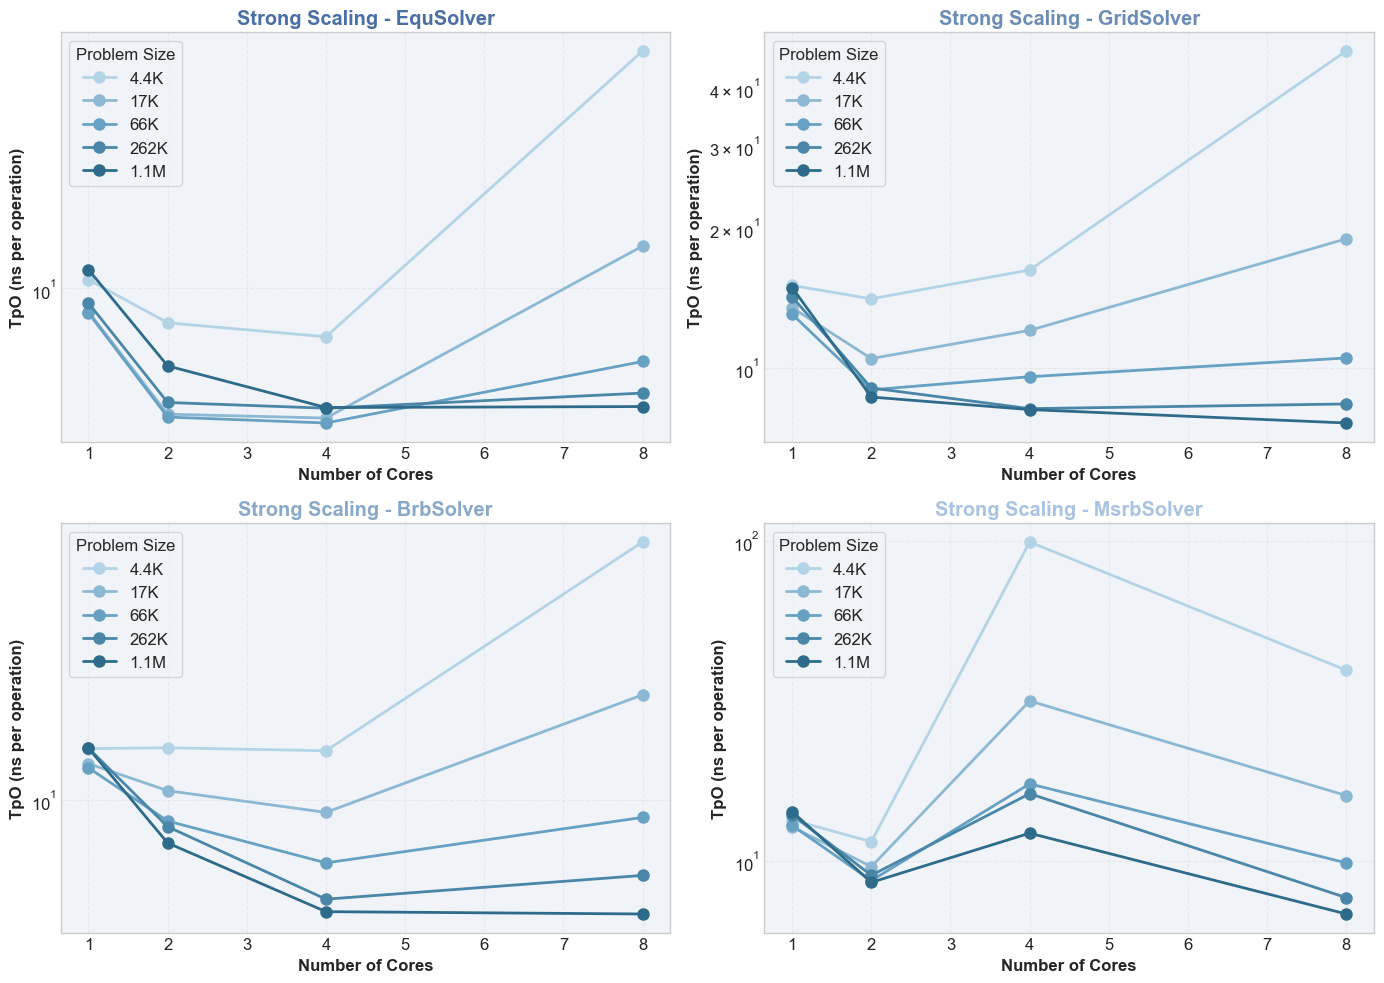

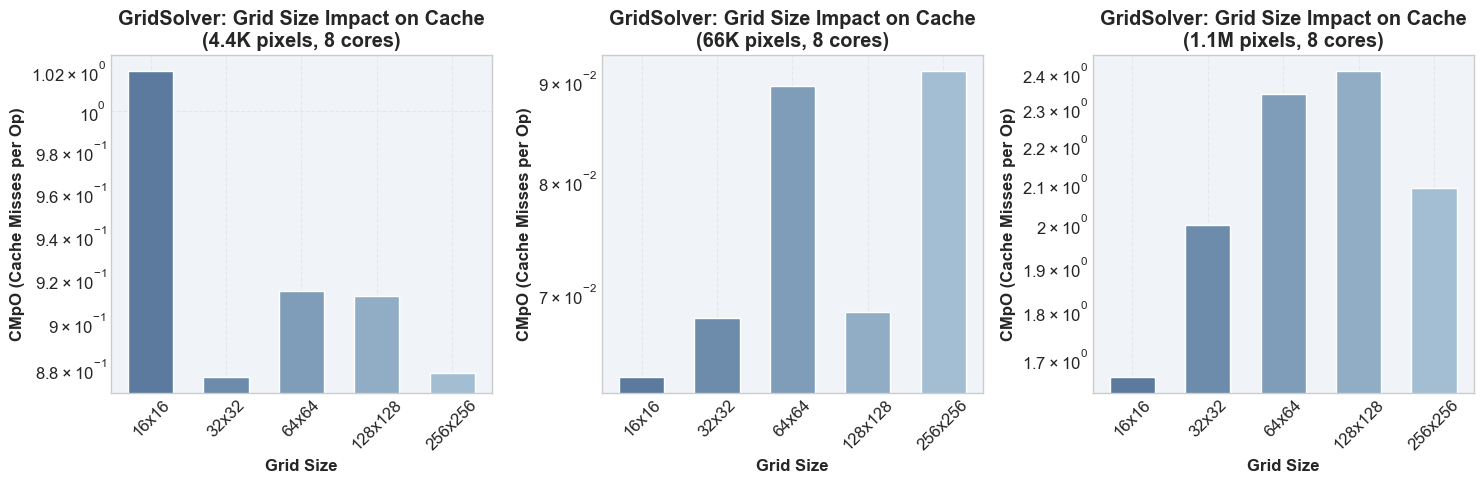

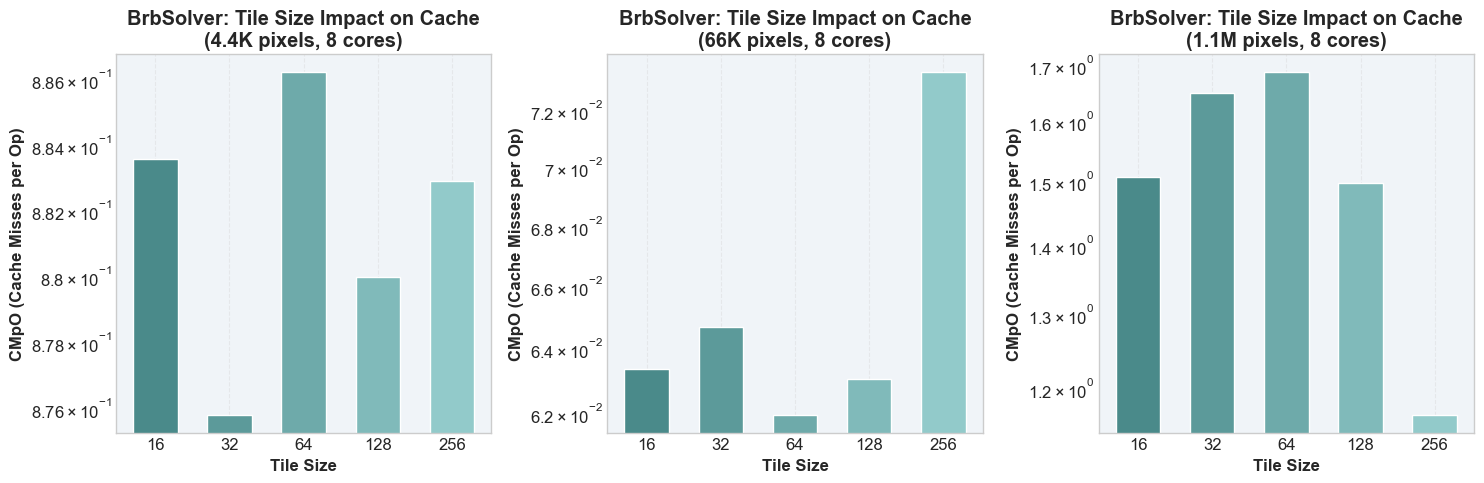

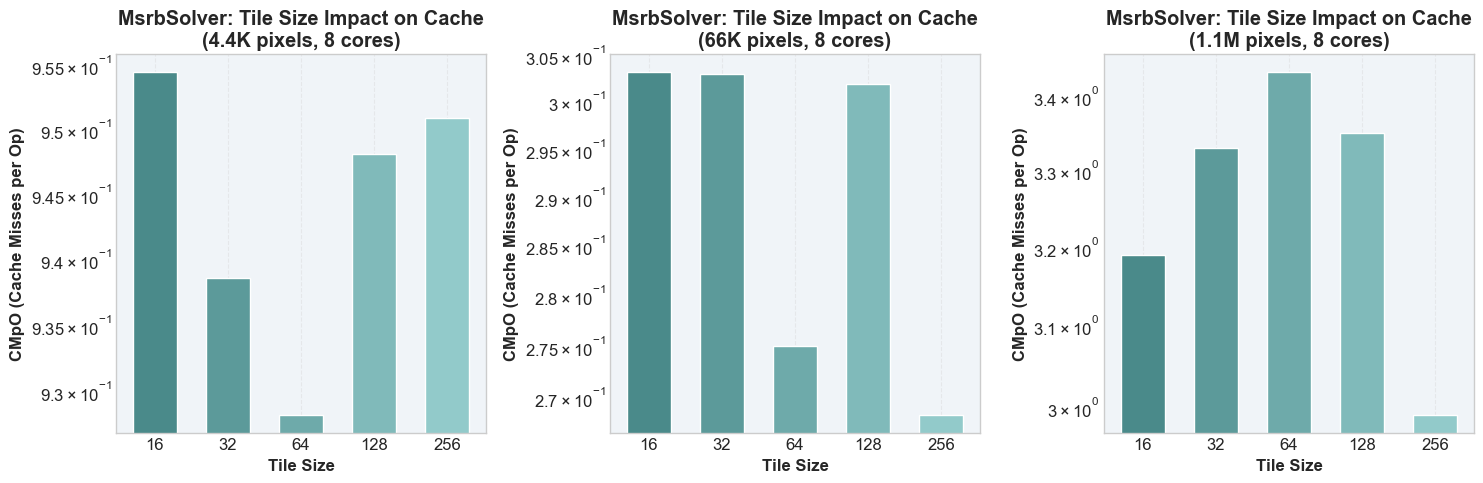

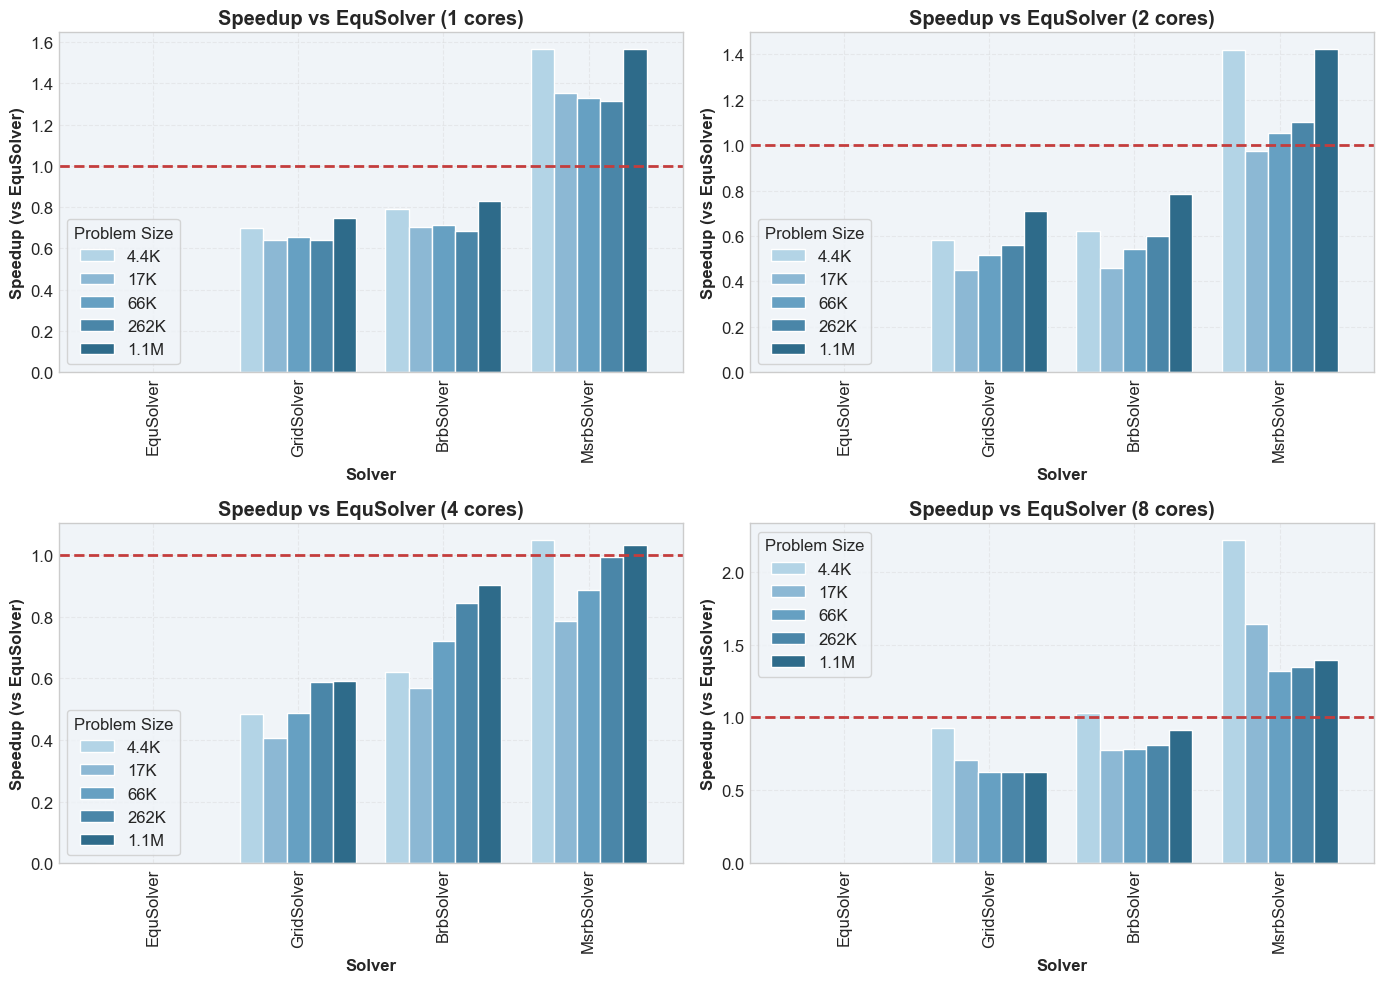

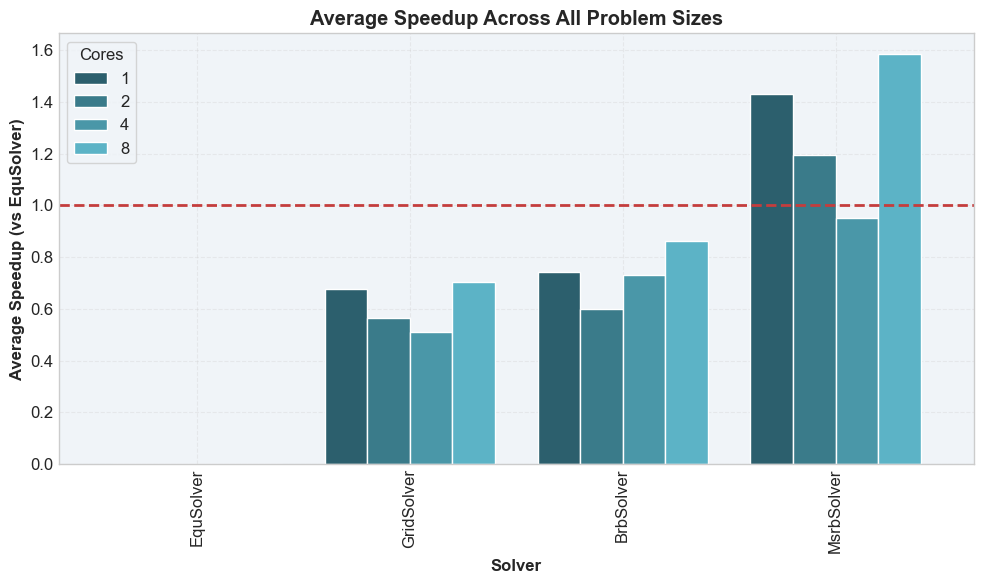


=== Average Speedup vs EquSolver ===

GridSolver:
  1 cores: 0.68x
  2 cores: 0.56x
  4 cores: 0.51x
  8 cores: 0.70x
BrbSolver:
  1 cores: 0.74x
  2 cores: 0.60x
  4 cores: 0.73x
  8 cores: 0.86x
MsrbSolver:
  1 cores: 1.43x
  2 cores: 1.19x
  4 cores: 0.95x
  8 cores: 1.58x


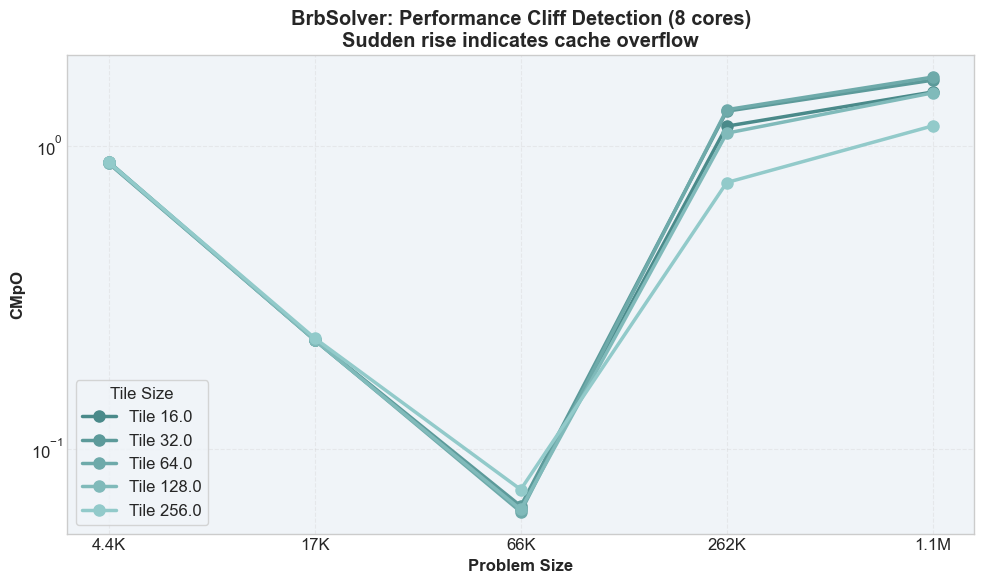

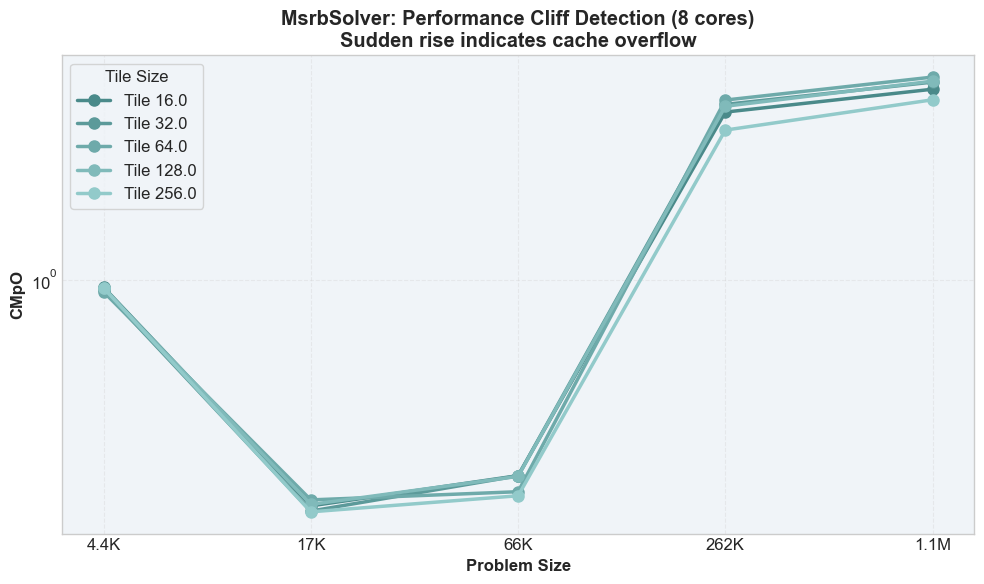

Cleaned data exported to plots/clean_benchmark_data.csv


In [17]:
# %% [markdown]
# # Poisson Image Editing Benchmark Visualization
# 
# This notebook plots performance metrics using appropriate chart types:
# - Bar charts for categorical comparisons (solvers, grid sizes, tile sizes)
# - Line graphs for scaling trends (core count scaling, problem size scaling)

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================================
# CONSISTENT COOL/MUTED COLOR SCHEME
# ============================================================

# Solver colors - ORDERED: Equ, Grid, Brb, Msrb
solver_colors = {
    'EquSolver': '#4A6FA5',    # Muted steel blue (baseline)
    'GridSolver': '#6B8DB5',   # Soft blue-grey
    'BrbSolver': '#89A9C9',    # Pale blue
    'MsrbSolver': '#A8C4E0'    # Light powder blue (most advanced)
}

# Core colors - gradient of cool teals
core_colors = {
    1: '#2C5F6D',      # Deep teal
    2: '#3A7B8A',      # Medium teal
    4: '#4A97A8',      # Lighter teal
    8: '#5CB3C6'       # Soft teal
}

# Problem size colors - gradient from light to dark blue
size_colors = {
    '4.4K': '#B3D4E6',   # Very light blue
    '17K': '#8CB8D4',    # Light blue
    '66K': '#66A0C2',    # Medium-light blue
    '262K': '#4A86A8',   # Medium blue
    '1.1M': '#2E6B8A'    # Dark blue
}

# Grid size colors for bar charts (Slate Blues)
grid_size_colors = {
    '16x16': '#5C7A9E',
    '32x32': '#6D8BAB',
    '64x64': '#7F9CB8',
    '128x128': '#91ADC5',
    '256x256': '#A3BED2'
}

# Tile size colors for bar charts (Seafoam/Sage)
tile_size_colors = {
    16: '#4A8A8A',
    32: '#5C9A9A',
    64: '#6EAAAA',
    128: '#80BABA',
    256: '#92CACA'
}


# Define solver order for consistent plotting
SOLVER_ORDER = ['EquSolver', 'GridSolver', 'BrbSolver', 'MsrbSolver']

# ============================================================
# PLOT STYLE CONFIGURATION
# ============================================================

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.facecolor'] = '#F0F4F8'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

Path('plots').mkdir(parents=True, exist_ok=True)

# %% [code]
# Load the CSV results
csv_path = "results/benchmark_results.csv"
df = pd.read_csv(csv_path)

# Clean and prepare data
numeric_cols = ['pixels', 'cores', 'time_seconds','tile_size', 'actual_iterations', 'n_vars', 'tpo_ns', 'cmpo', 'cache_misses', 'cache_references']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Filter out invalid rows
df = df.dropna(subset=['tpo_ns', 'cmpo', 'cores', 'pixels'])
df = df[df['tpo_ns'] > 0]
df = df[df['cmpo'] > 0]

# Calculate cache miss rate
df['cache_miss_rate'] = df['cache_misses'] / df['cache_references'] * 100

# Round problem sizes for cleaner grouping
def round_pixels(p):
    if p >= 1000000:
        return 1052676
    elif p >= 260000:
        return 264196
    elif p >= 66000:
        return 66564
    elif p >= 16000:
        return 16900
    elif p >= 4000:
        return 4356
    else:
        return p

df['pixels_rounded'] = df['pixels'].apply(round_pixels)

# Add readable size labels
def size_label(p):
    if p >= 1052676:
        return '1.1M'
    elif p >= 264196:
        return '262K'
    elif p >= 66564:
        return '66K'
    elif p >= 16900:
        return '17K'
    elif p >= 4356:
        return '4.4K'
    else:
        return str(p)

df['size_label'] = df['pixels_rounded'].apply(size_label)
df['grid_label'] = df['grid_x'].astype(str) + 'x' + df['grid_y'].astype(str)

print(f"Loaded {len(df)} valid benchmark entries")
print(f"Solvers: {df['solver'].unique()}")
print(f"Cores: {sorted(df['cores'].unique())}")

# %% [markdown]
# ## 1. TpO Comparison - Bar Chart (Grouped by Solver, Faceted by Core Count)

# %% [code]
problem_sizes = [4356, 66564, 1052676]
size_labels_dict = {4356: '4.4K pixels', 66564: '66K pixels', 1052676: '1.1M pixels'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, pixels in enumerate(problem_sizes):
    ax = axes[idx]
    subset = df[df['pixels'] == pixels]
    # Reindex to enforce solver order
    pivot = subset.pivot_table(index='solver', columns='cores', values='tpo_ns', aggfunc='mean')
    pivot = pivot.reindex(SOLVER_ORDER)
    
    pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=1,
               color=[core_colors.get(c, '#888888') for c in pivot.columns])
    
    ax.set_xlabel('Solver', fontweight='bold')
    ax.set_ylabel('TpO (ns per operation)', fontweight='bold')
    ax.set_title(f'TpO Comparison ({size_labels_dict[pixels]})', fontweight='bold')
    ax.set_yscale('log')
    ax.legend(title='Cores', frameon=True)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/tpo_bar_chart.png', dpi=200, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 2. CMpO Comparison - Bar Chart (Grouped by Solver, Faceted by Core Count)

# %% [code]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, pixels in enumerate(problem_sizes):
    ax = axes[idx]
    subset = df[df['pixels'] == pixels]
    pivot = subset.pivot_table(index='solver', columns='cores', values='cmpo', aggfunc='mean')
    pivot = pivot.reindex(SOLVER_ORDER)
    
    pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=1,
               color=[core_colors.get(c, '#888888') for c in pivot.columns])
    
    ax.set_xlabel('Solver', fontweight='bold')
    ax.set_ylabel('CMpO (Cache Misses per Operation)', fontweight='bold')
    ax.set_title(f'CMpO Comparison ({size_labels_dict[pixels]})', fontweight='bold')
    ax.set_yscale('log')
    ax.legend(title='Cores', frameon=True)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/cmpo_bar_chart.png', dpi=200, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 3. Strong Scaling - LINE GRAPH (TpO vs Cores)

# %% [code]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, solver in enumerate(SOLVER_ORDER):
    ax = axes[idx]
    subset = df[df['solver'] == solver]
    
    # Group by cores and problem size
    scaling_data = subset.groupby(['cores', 'size_label'])['tpo_ns'].mean().unstack()
    size_order = ['4.4K', '17K', '66K', '262K', '1.1M']
    scaling_data = scaling_data.reindex(columns=[s for s in size_order if s in scaling_data.columns])
    
    for size in scaling_data.columns:
        ax.plot(scaling_data.index, scaling_data[size], 'o-', linewidth=2, markersize=8,
               color=size_colors[size], label=size)
    
    ax.set_xlabel('Number of Cores', fontweight='bold')
    ax.set_ylabel('TpO (ns per operation)', fontweight='bold')
    ax.set_title(f'Strong Scaling - {solver}', fontweight='bold', color=solver_colors[solver])
    ax.set_yscale('log')
    ax.legend(title='Problem Size', frameon=True)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/strong_scaling_line.png', dpi=200, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 4b. Grid Size Analysis - BAR CHART (CMpO for GridSolver)

# %% [code]
grid_df = df[df['solver'] == 'GridSolver']
grid_df = grid_df[grid_df['cores'] == 8]

if not grid_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    grid_order = ['16x16', '32x32', '64x64', '128x128', '256x256']
    
    for idx, pixels in enumerate(problem_sizes):
        ax = axes[idx]
        subset = grid_df[grid_df['pixels'] == pixels]
        
        # Prepare CMpO data
        grid_data = []
        for g in grid_order:
            val = subset[subset['grid_label'] == g]['cmpo'].values
            grid_data.append(val[0] if len(val) > 0 else 0)
        
        bars = ax.bar(grid_order, grid_data, width=0.6, 
                     color=[grid_size_colors.get(g, '#888888') for g in grid_order],
                     edgecolor='white', linewidth=1)
        
        ax.set_xlabel('Grid Size', fontweight='bold')
        ax.set_ylabel('CMpO (Cache Misses per Op)', fontweight='bold')
        ax.set_title(f'GridSolver: Grid Size Impact on Cache\n({size_labels_dict[pixels]}, 8 cores)', fontweight='bold')
        
        # Log scale is helpful here as CMpO often spikes 
        # when grid dimensions exceed cache capacity
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('plots/gridsize_cmpo_analysis.png', dpi=200, bbox_inches='tight')
    plt.show()

# %% [markdown]
# ## 5b. Tile Size Analysis - BAR CHART (CMpO for BrbSolver & MsrbSolver)

# %% [code]
for solver_name in ['BrbSolver', 'MsrbSolver']:
    solver_df = df[df['solver'] == solver_name]
    solver_df = solver_df[solver_df['cores'] == 8]
    
    if not solver_df.empty:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        tile_order = [16, 32, 64, 128, 256]
        
        for idx, pixels in enumerate(problem_sizes):
            ax = axes[idx]
            subset = solver_df[solver_df['pixels'] == pixels]
            
            # Prepare CMpO data
            tile_data = []
            for t in tile_order:
                val = subset[subset['tile_size'] == t]['cmpo'].values
                tile_data.append(val[0] if len(val) > 0 else 0)
            
            bars = ax.bar([str(t) for t in tile_order], tile_data, width=0.6,
                          color=[tile_size_colors.get(t, '#888888') for t in tile_order],
                          edgecolor='white', linewidth=1)
            
            ax.set_xlabel('Tile Size', fontweight='bold')
            ax.set_ylabel('CMpO (Cache Misses per Op)', fontweight='bold')
            ax.set_title(f'{solver_name}: Tile Size Impact on Cache\n({size_labels_dict[pixels]}, 8 cores)', fontweight='bold')
            
            # Using log scale as cache misses can vary significantly across tile sizes
            ax.set_yscale('log')
            ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(f'plots/{solver_name.lower()}_tilesize_cmpo_analysis.png', dpi=200, bbox_inches='tight')
        plt.show()


# %% [markdown]
# ## 8. Speedup Bar Chart (vs EquSolver Baseline)

# %% [code]
equ_baseline = df[df['solver'] == 'EquSolver'][['cores', 'pixels', 'tpo_ns']].rename(
    columns={'tpo_ns': 'baseline_tpo'}
)

other_solvers = df[df['solver'] != 'EquSolver'].copy()
merged = other_solvers.merge(equ_baseline, on=['cores', 'pixels'])
merged['speedup'] = merged['baseline_tpo'] / merged['tpo_ns']
merged['size_label'] = merged['pixels'].apply(round_pixels).apply(size_label)

core_counts_plot = [1, 2, 4, 8]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, cores in enumerate(core_counts_plot):
    ax = axes[idx]
    subset = merged[merged['cores'] == cores]
    pivot = subset.pivot_table(index='solver', columns='size_label', values='speedup', aggfunc='mean')
    pivot = pivot.reindex(SOLVER_ORDER)
    
    size_order = ['4.4K', '17K', '66K', '262K', '1.1M']
    pivot = pivot.reindex(columns=[s for s in size_order if s in pivot.columns])
    
    pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=1,
               color=[size_colors.get(s, '#888888') for s in pivot.columns])
    
    ax.set_xlabel('Solver', fontweight='bold')
    ax.set_ylabel('Speedup (vs EquSolver)', fontweight='bold')
    ax.set_title(f'Speedup vs EquSolver ({cores} cores)', fontweight='bold')
    ax.axhline(y=1.0, color='#C43D3D', linestyle='--', linewidth=2)
    ax.legend(title='Problem Size', frameon=True)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/speedup_bar_chart.png', dpi=200, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 9. Average Speedup Summary - Bar Chart

# %% [code]
avg_speedup = merged.groupby(['solver', 'cores'])['speedup'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
pivot_avg = avg_speedup.pivot_table(index='solver', columns='cores', values='speedup', aggfunc='mean')
pivot_avg = pivot_avg.reindex(SOLVER_ORDER)

pivot_avg.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=1,
               color=[core_colors.get(c, '#888888') for c in pivot_avg.columns])

ax.set_xlabel('Solver', fontweight='bold')
ax.set_ylabel('Average Speedup (vs EquSolver)', fontweight='bold')
ax.set_title('Average Speedup Across All Problem Sizes', fontweight='bold')
ax.axhline(y=1.0, color='#C43D3D', linestyle='--', linewidth=2)
ax.legend(title='Cores', frameon=True)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/avg_speedup_bar.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n=== Average Speedup vs EquSolver ===\n")
for solver in SOLVER_ORDER:
    if solver in avg_speedup['solver'].values:
        print(f"{solver}:")
        for cores in [1, 2, 4, 8]:
            val = avg_speedup[(avg_speedup['solver'] == solver) & (avg_speedup['cores'] == cores)]['speedup'].values
            if len(val) > 0:
                print(f"  {cores} cores: {val[0]:.2f}x")

# %% [markdown]
# ## 10. Performance Cliff Detection - Line Graph

# %% [code]
for solver_name in ['BrbSolver', 'MsrbSolver']:
    solver_df = df[df['solver'] == solver_name]
    solver_df = solver_df[solver_df['cores'] == 8]
    
    if not solver_df.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        for tile in sorted(solver_df['tile_size'].unique()):
            subset = solver_df[solver_df['tile_size'] == tile]
            sizes = []
            cmpos = []
            for s in ['4.4K', '17K', '66K', '262K', '1.1M']:
                val = subset[subset['size_label'] == s]['cmpo'].values
                if len(val) > 0:
                    sizes.append(s)
                    cmpos.append(val[0])
            
            ax.plot(sizes, cmpos, 'o-', linewidth=2.5, markersize=8,
                   label=f'Tile {tile}', color=tile_size_colors.get(tile, '#888888'))
        
        ax.set_xlabel('Problem Size', fontweight='bold')
        ax.set_ylabel('CMpO', fontweight='bold')
        ax.set_title(f'{solver_name}: Performance Cliff Detection (8 cores)\nSudden rise indicates cache overflow', fontweight='bold')
        ax.set_yscale('log')
        ax.legend(title='Tile Size', frameon=True)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'plots/{solver_name.lower()}_performance_cliff_line.png', dpi=200, bbox_inches='tight')
        plt.show()

# %% [markdown]
# ## 11. Export Cleaned Data

# %% [code]
filtered_export = df[['solver', 'cores', 'pixels', 'pixels_rounded', 'size_label', 
                      'tile_size', 'grid_x', 'grid_y', 'grid_label',
                      'time_seconds', 'actual_iterations', 'tpo_ns', 'cmpo', 
                      'cache_misses', 'cache_references', 'cache_miss_rate']].copy()
filtered_export.to_csv('plots/clean_benchmark_data.csv', index=False)
print("Cleaned data exported to plots/clean_benchmark_data.csv")